## Imports

In [1]:
import sys
import os
import torch
import torch.utils.data as data
import torch.nn as nn

sys.path.append(os.path.abspath('../../'))

import EXP_neuro_fuzzy_toolbox as nft

## Data

In [50]:
x_train = 2 * torch.rand(200, 2) - 1
x_train

tensor([[ 0.5121,  0.6088],
        [-0.4029, -0.0923],
        [ 0.1192,  0.0699],
        [-0.7997,  0.6974],
        [-0.1784, -0.5597],
        [ 0.8236,  0.4338],
        [-0.3742, -0.4027],
        [-0.9897, -0.8916],
        [-0.2732, -0.6115],
        [-0.5115,  0.0718],
        [-0.7175,  0.7870],
        [ 0.4517,  0.5318],
        [-0.8537,  0.9443],
        [ 0.6086,  0.5757],
        [-0.1599,  0.2276],
        [-0.2886,  0.1643],
        [ 0.4906, -0.1289],
        [-0.9441,  0.8378],
        [ 0.7118,  0.9562],
        [-0.4097,  0.9456],
        [-0.7960,  0.2583],
        [ 0.7200,  0.9400],
        [-0.6405, -0.8768],
        [-0.0498,  0.6780],
        [ 0.7071,  0.8828],
        [-0.3875, -0.3268],
        [-0.1324, -0.4541],
        [-0.4360,  0.8109],
        [-0.5481,  0.4776],
        [-0.0869, -0.6135],
        [ 0.3102, -0.5012],
        [ 0.7070, -0.2560],
        [ 0.8987, -0.3885],
        [-0.7249,  0.4070],
        [-0.9171,  0.7205],
        [-0.6514, -0

In [51]:
y_train = torch.rand(200)
y_train

tensor([0.7335, 0.6504, 0.3117, 0.4692, 0.4751, 0.9609, 0.8287, 0.6052, 0.9961,
        0.1056, 0.9465, 0.6359, 0.5850, 0.6638, 0.0243, 0.0177, 0.4079, 0.7721,
        0.3444, 0.5280, 0.9696, 0.2010, 0.6001, 0.6112, 0.6364, 0.5787, 0.0690,
        0.4430, 0.0278, 0.2340, 0.1131, 0.2310, 0.6172, 0.3109, 0.5882, 0.0977,
        0.5782, 0.2885, 0.1969, 0.2570, 0.8360, 0.9528, 0.5920, 0.2246, 0.9873,
        0.5507, 0.4414, 0.8153, 0.6823, 0.8814, 0.5179, 0.9721, 0.8933, 0.3899,
        0.7326, 0.3646, 0.7137, 0.7146, 0.7625, 0.5874, 0.9342, 0.8707, 0.9930,
        0.1108, 0.3648, 0.5857, 0.1937, 0.5138, 0.7227, 0.5093, 0.7524, 0.8938,
        0.1883, 0.1126, 0.5559, 0.7540, 0.1961, 0.6092, 0.8495, 0.9390, 0.4501,
        0.3927, 0.1489, 0.9134, 0.6206, 0.8228, 0.3157, 0.8930, 0.8134, 0.7950,
        0.7617, 0.9030, 0.6869, 0.5974, 0.6830, 0.8889, 0.0673, 0.2774, 0.0795,
        0.0836, 0.6345, 0.9301, 0.1601, 0.3271, 0.6589, 0.3337, 0.5120, 0.0059,
        0.9803, 0.7092, 0.8813, 0.1257, 

## Model

In [54]:
model = nft.rule_reduced_ANFIS(
    input_size=x_train.shape[1], # 3 features
    num_mfs=3, # 4 funciones de membresía
    outputs=1, # 1 salida
    membership_function=nft.GeneralizedBell_MF, # Función de membresía gaussiana
    output_type='default', # Tipo de salida: default
)

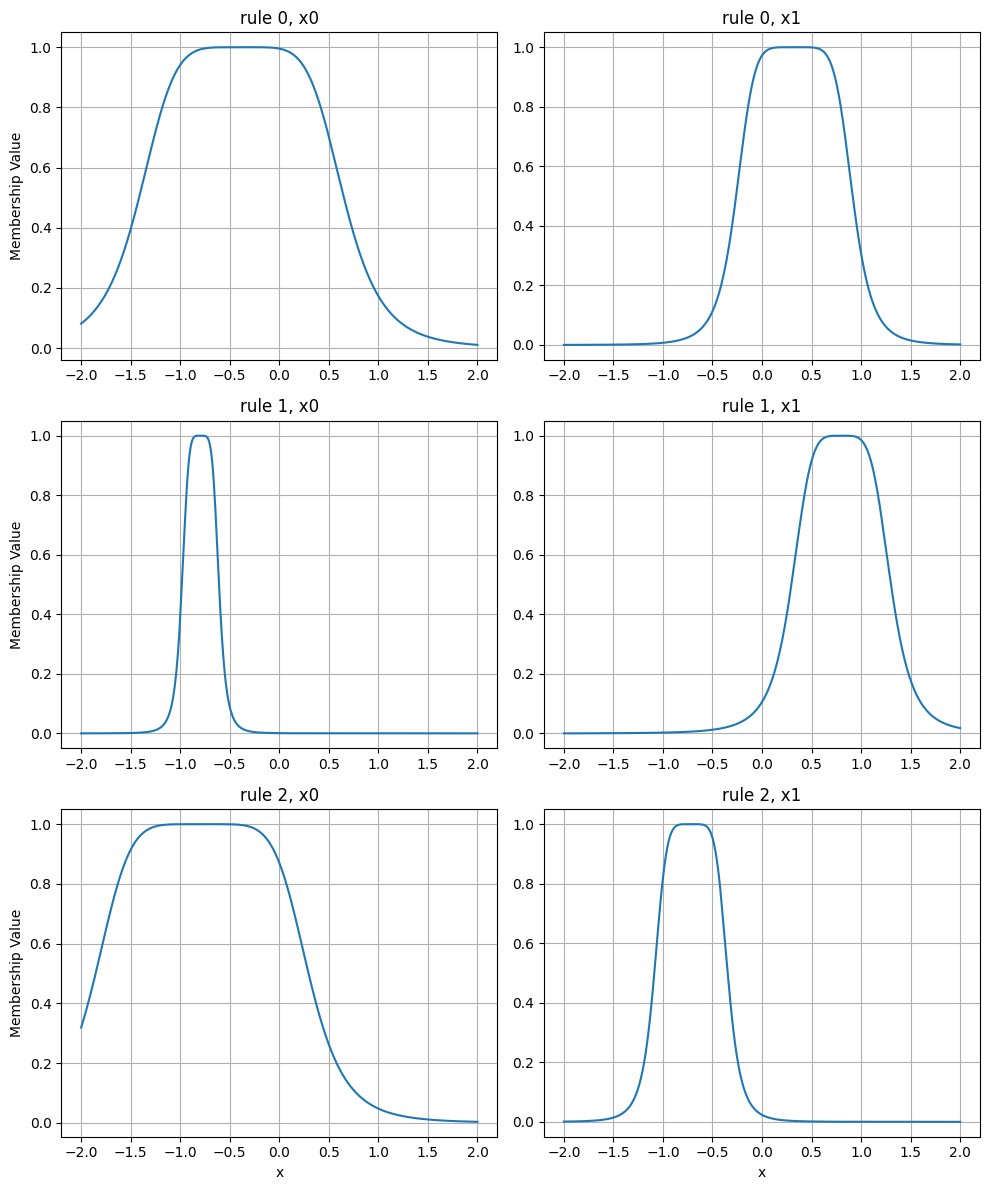

In [55]:
model.plot_premises()

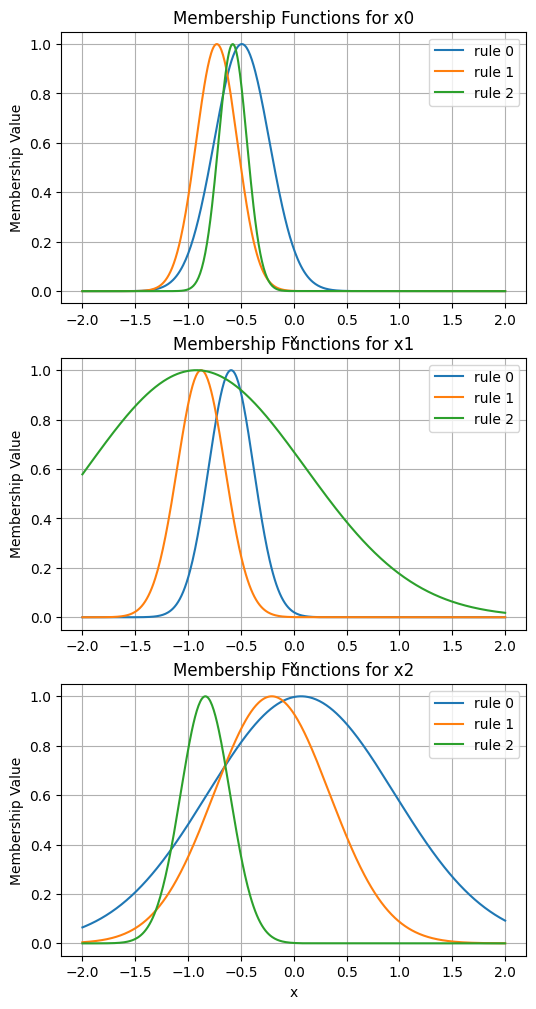

In [6]:
model.plot_premises(group_by_dim=True)

In [7]:
model.get_premises_structure()

x0                  x1                  x2          
              mu     sigma        mu     sigma        mu     sigma
rule 0 -0.491558  0.261573 -0.592741  0.212782  0.069022  0.883937
rule 1 -0.728246  0.194636 -0.876454  0.225952 -0.207775  0.546573
rule 2 -0.577564  0.134445 -0.921932  1.030352 -0.836618  0.233689

In [8]:
model.get_premises()

tensor([[[-0.4916,  0.2616],
         [-0.7282,  0.1946],
         [-0.5776,  0.1344]],

        [[-0.5927,  0.2128],
         [-0.8765,  0.2260],
         [-0.9219,  1.0304]],

        [[ 0.0690,  0.8839],
         [-0.2078,  0.5466],
         [-0.8366,  0.2337]]])

In [9]:
model.get_consequents_structure()[0]

,x0,x1,x2,
,c0,c1,c2,c3
rule 1,0.992522,0.278547,-0.111834,0.748904
rule 2,0.021353,0.918463,-0.283754,0.146793
rule 3,-0.248804,-0.655908,-0.423098,-0.604938


In [10]:
model.init_consequents(x_train, y_train)

In [11]:
model.get_consequents_structure()[0]

,x0,x1,x2,
,c0,c1,c2,c3
rule 1,0.015244,0.077277,0.062807,0.485933
rule 2,-0.652891,1.304353,0.247703,1.107484
rule 3,0.079900,-0.237257,0.072664,0.766940


In [12]:
model.get_rules_structure()

premises                                                    \
              x0                  x1                  x2             
              mu     sigma        mu     sigma        mu     sigma   
rule 1 -0.491558  0.261573 -0.592741  0.212782  0.069022  0.883937   
rule 2 -0.728246  0.194636 -0.876454  0.225952 -0.207775  0.546573   
rule 3 -0.577564  0.134445 -0.921932  1.030352 -0.836618  0.233689   

       output 1 consequents                                
                         x0        x1        x2            
                         c0        c1        c2        c3  
rule 1             0.015244  0.077277  0.062807  0.485933  
rule 2            -0.652891  1.304353  0.247703  1.107484  
rule 3             0.079900 -0.237257  0.072664  0.766940

In [13]:
model(x_train[:10])

tensor([0.4811, 0.6574, 0.4860, 0.5297, 0.5050, 0.3707, 0.3841, 0.6198, 0.6127,
        0.6132], grad_fn=<SqueezeBackward1>)

In [14]:
with torch.no_grad():
    output = model(x_train[:10])

print(output)

tensor([0.4811, 0.6574, 0.4860, 0.5297, 0.5050, 0.3707, 0.3841, 0.6198, 0.6127,
        0.6132])


In [15]:
model.predict(x_train[:10])

array([0.48107195, 0.6574016 , 0.48596957, 0.52972615, 0.50495243,
       0.37069944, 0.3840565 , 0.6198019 , 0.61273474, 0.6132292 ],
      dtype=float32)

## Binary output

In [16]:
x_train = 2 * torch.rand(200, 3) - 1

In [17]:
y_train = torch.randint(0, 2, (200,))
y_train[:10]

tensor([1, 0, 0, 0, 1, 0, 0, 0, 1, 1])

In [18]:
bin_model = nft.h_ANFIS(
    input_size=x_train.shape[1], # 3 features
    num_mfs=3, # 4 funciones de membresía
    outputs=1, # 1 salida
    membership_function=nft.Gaussian_MF, # Función de membresía gaussiana
    output_type='sigmoid', # Tipo de salida: clasificación binaria
)

In [19]:
bin_model.predict(x_train[:10])

array([0, 1, 0, 0, 1, 0, 0, 1, 1, 0])

In [20]:
bin_model(x_train[:10])

tensor([0.3439, 0.5044, 0.4299, 0.4905, 0.5033, 0.4059, 0.4239, 0.5374, 0.5656,
        0.4111], grad_fn=<SigmoidBackward0>)

## Multiclass output

In [21]:
x_train = 2 * torch.rand(200, 3) - 1

In [22]:
y_train = torch.randint(0, 4, (200,))
y_train[:10]

tensor([2, 0, 2, 2, 3, 0, 0, 2, 2, 0])

In [23]:
mul_class_model = nft.h_ANFIS(
    input_size=x_train.shape[1], # 3 features
    num_mfs=3, # 3 funciones de membresía
    outputs=4, # 4 clases
    membership_function=nft.Gaussian_MF, # Función de membresía gaussiana
    output_type='softmax', # Tipo de salida: clasificación multiclase
)

In [24]:
mul_class_model.predict(x_train[:10])

array([3, 1, 1, 3, 3, 1, 2, 3, 1, 1])

In [25]:
mul_class_model(x_train[:10])

tensor([[-0.0830,  0.3054,  0.1835,  0.4458],
        [ 0.4430,  0.5495, -0.0112, -0.0034],
        [-0.2083,  1.4874, -0.3745,  0.4799],
        [-0.0911, -0.2165, -0.0221,  0.1987],
        [-0.2218,  0.0692, -0.1205,  0.4148],
        [ 0.0754,  1.1849, -0.2885,  0.5283],
        [ 0.0526, -0.0747,  0.4656,  0.1927],
        [-0.0156, -0.1349, -0.0041,  0.2401],
        [ 0.3657,  0.4731, -0.5205, -0.5129],
        [ 0.3364,  0.5997, -0.5199, -0.5123]], grad_fn=<SqueezeBackward1>)

In [26]:
mul_class_model(x_train[:10], return_probabilities=True)

tensor([[0.1826, 0.2693, 0.2383, 0.3098],
        [0.2952, 0.3284, 0.1874, 0.1889],
        [0.1077, 0.5869, 0.0912, 0.2143],
        [0.2331, 0.2056, 0.2498, 0.3115],
        [0.1875, 0.2508, 0.2075, 0.3543],
        [0.1587, 0.4814, 0.1103, 0.2496],
        [0.2202, 0.1938, 0.3327, 0.2533],
        [0.2386, 0.2118, 0.2414, 0.3082],
        [0.3400, 0.3786, 0.1402, 0.1412],
        [0.3171, 0.4126, 0.1347, 0.1357]], grad_fn=<SoftmaxBackward0>)

In [27]:
mul_class_model.get_rules_structure()

premises                                                    \
               x0                  x1                  x2             
               mu     sigma        mu     sigma        mu     sigma   
rule 1   0.285874  0.227359  0.662894  0.177038  0.400937  0.491046   
rule 2   0.285874  0.227359  0.662894  0.177038 -0.531998  0.190861   
rule 3   0.285874  0.227359  0.662894  0.177038  0.098165  0.593007   
rule 4   0.285874  0.227359  0.722727  1.041094  0.400937  0.491046   
rule 5   0.285874  0.227359  0.722727  1.041094 -0.531998  0.190861   
rule 6   0.285874  0.227359  0.722727  1.041094  0.098165  0.593007   
rule 7   0.285874  0.227359  0.961151  0.101998  0.400937  0.491046   
rule 8   0.285874  0.227359  0.961151  0.101998 -0.531998  0.190861   
rule 9   0.285874  0.227359  0.961151  0.101998  0.098165  0.593007   
rule 10  0.641076  0.851736  0.662894  0.177038  0.400937  0.491046   
rule 11  0.641076  0.851736  0.662894  0.177038 -0.531998  0.190861   
rule 12  0.641076  0.851736  0.662894  0.177038  0.098165  0.593007   
rule 13  0.641076  0.851736  0.722727  1.041094  0.400937  0.491046   
rule 14  0.641076  0.851736  0.722727  1.041094 -0.531998  0.190861   
rule 15  0.641076  0.851736  0.722727  1.041094  0.098165  0.593007   
rule 16  0.641076  0.851736  0.961151  0.101998  0.400937  0.491046   
rule 17  0.641076  0.851736  0.961151  0.101998 -0.531998  0.190861   
rule 18  0.641076  0.851736  0.961151  0.101998  0.098165  0.593007   
rule 19 -0.515656  0.216642  0.662894  0.177038  0.400937  0.491046   
rule 20 -0.515656  0.216642  0.662894  0.177038 -0.531998  0.190861   
rule 21 -0.515656  0.216642  0.662894  0.177038  0.098165  0.593007   
rule 22 -0.515656  0.216642  0.722727  1.041094  0.400937  0.491046   
rule 23 -0.515656  0.216642  0.722727  1.041094 -0.531998  0.190861   
rule 24 -0.515656  0.216642  0.722727  1.041094  0.098165  0.593007   
rule 25 -0.515656  0.216642  0.961151  0.101998  0.400937  0.491046   
rule 26 -0.515656  0.216642  0.961151  0.101998 -0.531998  0.190861   
rule 27 -0.515656  0.216642  0.961151  0.101998  0.098165  0.593007   

        output 1 consequents                                ...  \
                          x0        x1        x2            ...   
                          c0        c1        c2        c3  ...   
rule 1             -0.110727  0.584123  0.900639  0.324122  ...   
rule 2             -0.381877  0.067399  0.660008 -0.612744  ...   
rule 3             -0.017913 -0.428342  0.430006 -0.716668  ...   
rule 4              0.446810 -0.086941  0.574986  0.544170  ...   
rule 5              0.002085 -0.110314 -0.089472  0.710123  ...   
rule 6             -0.683252 -0.316907  0.498641 -0.842193  ...   
rule 7             -0.782628 -0.498343 -0.549723  0.946498  ...   
rule 8             -0.119623 -0.313782  0.087368  0.195266  ...   
rule 9              0.775284  0.240965 -0.060203  0.836581  ...   
rule 10             0.434124  0.947770  0.753145  0.945140  ...   
rule 11            -0.201858  0.756153  0.868216 -0.147792  ...   
rule 12            -0.271086 -0.795293  0.605036 -0.534961  ...   
rule 13             0.045337  0.958672 -0.810047 -0.034628  ...   
rule 14            -0.390255  0.908212 -0.343392  0.329309  ...   
rule 15             0.679017 -0.524011  0.523014  0.062026  ...   
rule 16             0.584782  0.358928  0.168135 -0.657824  ...   
rule 17            -0.096448  0.354817 -0.751574  0.546163  ...   
rule 18             0.511530  0.297301  0.585990  0.258532  ...   
rule 19             0.416848  0.118909 -0.887189  0.284479  ...   
rule 20            -0.358694 -0.844523  0.786055 -0.139794  ...   
rule 21            -0.164943  0.532092  0.383111 -0.996846  ...   
rule 22             0.711067  0.649761  0.213792  0.688810  ...   
rule 23             0.195439  0.893398  0.611418 -0.040336  ...   
rule 24            -0.876377 -0.993356  0.732872  0.017345  ...   
rule 25             0.511596  0.868811  0.405999  0.547835  ...   
ru

## Multiple outputs

In [28]:
x_train = 2 * torch.rand(200, 2) - 1

In [29]:
model = nft.h_ANFIS(
    input_size=x_train.shape[1], # 2 features
    num_mfs=3, # 3 funciones de membresía
    outputs=2, # 2 salidas
    membership_function=nft.Gaussian_MF, # Función de membresía gaussiana
    output_type='default', # Tipo de salida: regresión
)

In [30]:
model.get_consequents_structure()

[              x0        x1          
               c0        c1        c2
 rule 1 -0.678191 -0.247080  0.590183
 rule 2  0.689103 -0.508646 -0.353273
 rule 3 -0.304797 -0.784173 -0.084294
 rule 4 -0.202287  0.562831  0.331021
 rule 5 -0.863812 -0.972792  0.705085
 rule 6  0.318643  0.050276 -0.652522
 rule 7  0.048529 -0.603932  0.211605
 rule 8  0.127185 -0.725737 -0.002723
 rule 9  0.873846  0.247156  0.711832,
               x0        x1          
               c0        c1        c2
 rule 1 -0.490568 -0.462989  0.732751
 rule 2  0.795897 -0.471546 -0.599512
 rule 3  0.611823 -0.555058 -0.477063
 rule 4  0.575068  0.543803 -0.147956
 rule 5  0.377234 -0.224102  0.260775
 rule 6  0.682500  0.910589  0.361918
 rule 7  0.936956  0.795307  0.582294
 rule 8  0.412635 -0.904926 -0.370970
 rule 9 -0.416333 -0.688526  0.403111]

In [31]:
model(x_train[:10])

tensor([[ 0.4731,  0.5628],
        [-0.1357,  0.1894],
        [ 0.2284,  0.0633],
        [ 0.0661, -0.0842],
        [ 0.0323,  0.1903],
        [ 0.2628, -0.1868],
        [ 0.2417, -0.1732],
        [ 0.3139,  0.2678],
        [ 0.3074,  0.4000],
        [ 0.1948,  0.2624]], grad_fn=<SqueezeBackward1>)

## Multiclass problem

In [32]:
x_train = 2 * torch.rand(200, 2) - 1 # ejemplo de datos de entrenamiento con 2 features

model = nft.h_ANFIS(
    input_size=x_train.shape[1], # 3 features
    num_mfs=2, # 2 funciones de membresía
    outputs=3, # 3 salidas
    membership_function=nft.Gaussian_MF, # Función de membresía gaussiana
    output_type='softmax', # Tipo de salida: clasificación multiclase
)

In [33]:
model(x_train[:10])

tensor([[-0.3847,  0.0534,  0.7069],
        [-0.4254, -0.0105,  0.0935],
        [ 0.5820,  0.1409,  0.6199],
        [-0.8000, -0.1792, -0.4723],
        [-0.5894, -0.0338,  1.0169],
        [-1.0737,  0.0291, -0.5747],
        [ 0.1580, -0.1202,  0.1335],
        [-0.5553, -0.2687, -0.3081],
        [-0.4328, -0.7007, -0.3487],
        [-0.1807,  0.0205,  0.8073]], grad_fn=<SqueezeBackward1>)

In [34]:
model(x_train[:10], return_probabilities=True)

tensor([[0.1809, 0.2803, 0.5388],
        [0.2384, 0.3610, 0.4006],
        [0.3729, 0.2399, 0.3873],
        [0.2354, 0.4379, 0.3267],
        [0.1294, 0.2256, 0.6450],
        [0.1767, 0.5323, 0.2910],
        [0.3659, 0.2770, 0.3571],
        [0.2768, 0.3687, 0.3545],
        [0.3505, 0.2682, 0.3813],
        [0.2037, 0.2491, 0.5472]], grad_fn=<SoftmaxBackward0>)

In [35]:
model.predict(x_train[:10])

array([2, 2, 2, 1, 2, 1, 0, 1, 2, 2])

# Rule Reduced

In [36]:
x_train = 2 * torch.rand(200, 2) - 1 # ejemplo de datos de entrenamiento con 2 features

In [37]:
rr_model = nft.rule_reduced_ANFIS(
    input_size=x_train.shape[1], # 2 features
    num_mfs=3, # 3 funciones de membresía
    outputs=1, # 1 salida
)

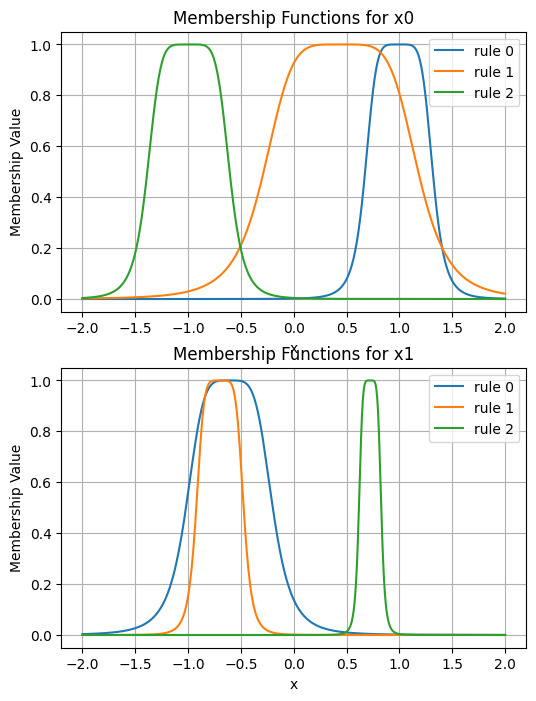

In [38]:
rr_model.plot_premises(group_by_dim=True)

In [39]:
rr_model.get_consequents_structure()[0]

,x0,x1,
,c0,c1,c2
rule 1,0.773847,0.857143,0.333553
rule 2,0.586813,0.982215,-0.847147
rule 3,-0.478634,0.836743,-0.610154


In [40]:
rr_model.get_rules_structure()

premises                                                    \
              x0                            x1                       
               a         b         c         a         b         c   
rule 1  0.320159  2.830406  0.995144  0.410825  2.322953 -0.609302   
rule 2  0.731487   2.55809  0.446247  0.224127  2.897039  -0.69852   
rule 3  0.389472  2.934871 -0.996426  0.105598  2.898091  0.722168   

       output 1 consequents                      
                         x0        x1            
                         c0        c1        c2  
rule 1             0.773847  0.857143  0.333553  
rule 2             0.586813  0.982215 -0.847147  
rule 3            -0.478634  0.836743 -0.610154